In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# Load Dataset
from google.colab import files
uploaded = files.upload()

import pandas as pd
df=pd.read_csv(list(uploaded.keys())[0])
df.head()

Saving house_prices.csv to house_prices (1).csv


,house_id,square_footage,number_of_rooms,number_of_bathrooms,lot_size_sqft,distance_to_city_center_km,year_built,has_garage,quality_score,school_rating,building_material,heating_type,price_k_usd
0,1000,1660,4,2.5,13501,28.8,2015,Yes,8,5,Stone,Gas,1077.78
1,1001,4572,5,3.5,10010,24.0,1986,No,6,4,Brick,Gas,1165.15
2,1002,3892,2,2.5,7959,12.6,1973,Yes,5,4,Wood,Electric,1077.08
3,1003,1266,4,2.0,9269,29.5,2011,Yes,5,4,Brick,Gas,919.52
4,1004,4244,5,2.5,9692,11.0,1970,Yes,3,2,Brick,Gas,1073.88


In [6]:
# Understand Data
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   house_id                    10000 non-null  int64  
 1   square_footage              10000 non-null  int64  
 2   number_of_rooms             10000 non-null  int64  
 3   number_of_bathrooms         10000 non-null  float64
 4   lot_size_sqft               10000 non-null  int64  
 5   distance_to_city_center_km  10000 non-null  float64
 6   year_built                  10000 non-null  int64  
 7   has_garage                  10000 non-null  object 
 8   quality_score               10000 non-null  int64  
 9   school_rating               10000 non-null  int64  
 10  building_material           10000 non-null  object 
 11  heating_type                10000 non-null  object 
 12  price_k_usd                 10000 non-null  float64
dtypes: float64(3), int64(7), object(

,house_id,square_footage,number_of_rooms,number_of_bathrooms,lot_size_sqft,distance_to_city_center_km,year_built,quality_score,school_rating,price_k_usd
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5999.50000,2906.349800,3.506800,2.277100,9523.834300,15.497810,1986.791200,6.508800,3.006800,1026.916494
std,2886.89568,1207.433822,1.114127,0.796322,3185.060018,8.362935,21.351946,2.287498,1.424485,192.863307
min,1000.00000,801.000000,2.000000,1.000000,4000.000000,1.000000,1950.000000,3.000000,1.000000,400.100000
25%,3499.75000,1847.500000,3.000000,2.000000,6774.750000,8.300000,1968.000000,4.000000,2.000000,889.025000
50%,5999.50000,2905.000000,4.000000,2.000000,9568.000000,15.400000,1987.000000,6.000000,3.000000,1027.705000
75%,8499.25000,3963.250000,5.000000,3.000000,12314.750000,22.700000,2005.000000,9.000000,4.000000,1167.295000
max,10999.00000,4999.000000,5.000000,4.000000,14999.000000,30.000000,2023.000000,10.000000,5.000000,1784.320000


In [7]:
#Clean Data
df.isnull().sum()
df=df.dropna()


In [9]:
# Select Features
x = df[['square_footage','number_of_rooms','number_of_bathrooms']]
y = df['price_k_usd']

In [11]:
# Train/Test Split
from sklearn.model_selection import train_test_split
x_tarin, x_test, y_train,y_test =train_test_split(x,y,test_size=0.2,random_state=42)


In [18]:
# Train Model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit (x_tarin,y_train)

LinearRegression()

In [19]:
# Prediction
y_pred = model.predict(x_test)

In [23]:
# Evaluation
from sklearn.metrics import mean_absolute_error , mean_squared_error

mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))

print("MAE:",mae)
print("RMSE:", rmse)

MAE: 96.64096335063645
RMSE: 121.52139005750533


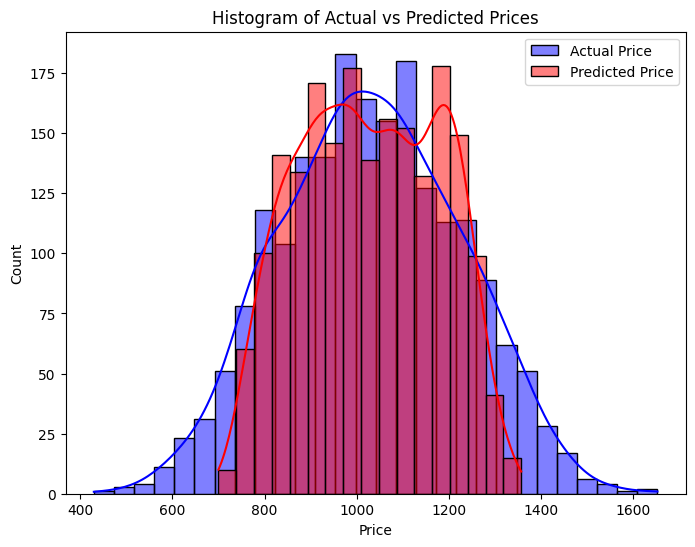

In [26]:
# Graph
import seaborn as sns
plt.figure(figsize=(8,6))

sns.histplot(y_test ,color="blue", label="Actual Price",kde=True)
sns.histplot(y_pred, color="red", label = "Predicted Price", kde=True)

plt.xlabel("Price")
plt.title("Histogram of Actual vs Predicted Prices")

plt.legend()
plt.show()
